# Assignment 3 - Customer Churn Prediction with a Tuned Neural Network


In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping


## Upload and Load Dataset

In [ ]:

from google.colab import files
uploaded = files.upload()

df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()


Saving WA_Fn-UseC_-Telco-Customer-Churn.csv to WA_Fn-UseC_-Telco-Customer-Churn (1).csv


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Task 1 - Explore & Clean

(7043, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null

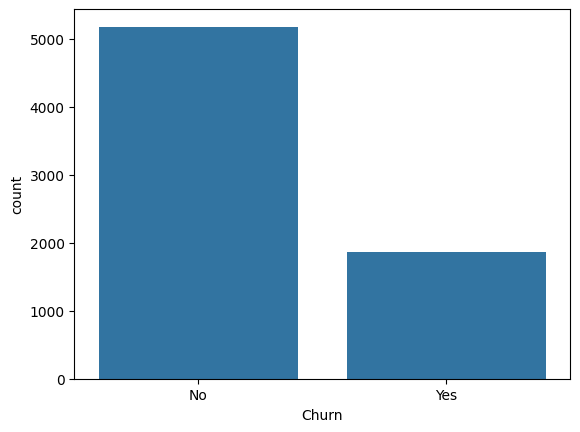

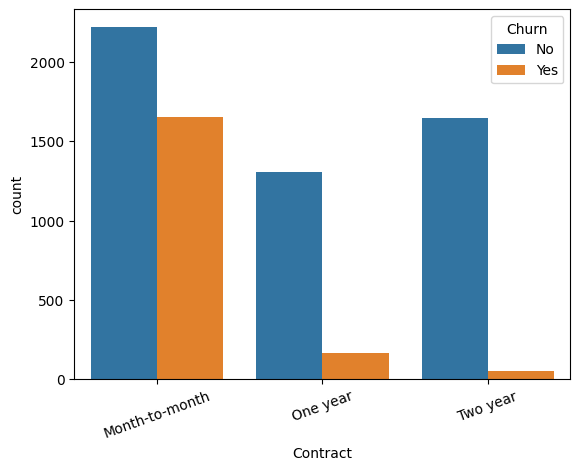

In [ ]:

print(df.shape)
print(df.info())
print(df.isnull().sum())

df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median())

sns.countplot(x="Churn", data=df)
plt.show()

sns.countplot(x="Contract", hue="Churn", data=df)
plt.xticks(rotation=20)
plt.show()

df.drop("customerID", axis=1, inplace=True)


## Task 2 - Preprocess

In [ ]:

le = LabelEncoder()
for c in df.columns:
    if df[c].dtype == "object":
        df[c] = le.fit_transform(df[c])

X = df.drop("Churn", axis=1)
y = df["Churn"]

scaler = StandardScaler()
X = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


## Task 3 - Baseline Model

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30
141/141 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7690 - loss: 0.4661 - val_accuracy: 0.7986 - val_loss: 0.4193
Epoch 2/30
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7925 - loss: 0.4289 - val_accuracy: 0.8039 - val_loss: 0.4171
Epoch 3/30
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7941 - loss: 0.4221 - val_accuracy: 0.8039 - val_loss: 0.4146
Epoch 4/30
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7996 - loss: 0.4184 - val_accuracy: 0.8083 - val_loss: 0.4110
Epoch 5/30
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8034 - loss: 0.4134 - val_accuracy: 0.7950 - val_loss: 0.4160
Epoch 6/30
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8043 - loss: 0.4106 - val_accuracy: 0.8012 - val_loss: 0.4150
Epoch 7/30
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8072 - loss: 0.4082 - val_accuracy: 0.7968 - val_loss: 0.4144
Epoch 8/30
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8092 - loss: 0.4046 - val_accuracy: 0.

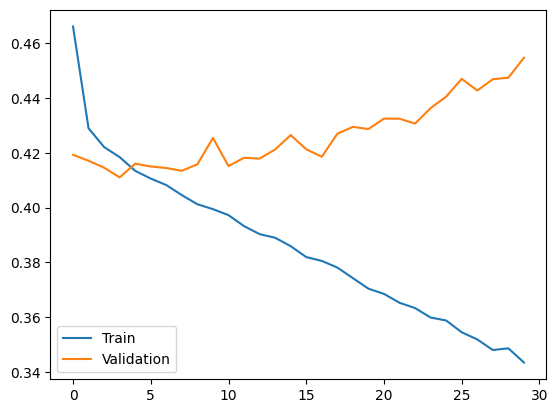

In [ ]:

baseline = Sequential([
    Dense(64, activation="relu", input_shape=(X_train.shape[1],)),
    Dense(32, activation="relu"),
    Dense(1, activation="sigmoid")
])

baseline.compile(optimizer="adam",
                 loss="binary_crossentropy",
                 metrics=["accuracy"])

history = baseline.fit(
    X_train, y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.2
)

baseline.evaluate(X_test, y_test)

plt.plot(history.history["loss"], label="Train")
plt.plot(history.history["val_loss"], label="Validation")
plt.legend()
plt.show()


## Task 4 - Tuned Model

In [ ]:

model = Sequential([
    Dense(64, activation="relu",
          kernel_regularizer=l2(0.001),
          input_shape=(X_train.shape[1],)),
    BatchNormalization(),
    Dropout(0.3),
    Dense(32, activation="relu",
          kernel_regularizer=l2(0.001)),
    Dropout(0.2),
    Dense(1, activation="sigmoid")
])

model.compile(optimizer="adam",
              loss="binary_crossentropy",
              metrics=["accuracy"])

early = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history2 = model.fit(
    X_train, y_train,
    epochs=100,
    validation_split=0.2,
    callbacks=[early]
)

print("Baseline Accuracy:", baseline.evaluate(X_test, y_test)[1])
print("Tuned Accuracy:", model.evaluate(X_test, y_test)[1])


Epoch 1/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.6858 - loss: 0.6735 - val_accuracy: 0.7728 - val_loss: 0.5178
Epoch 2/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7595 - loss: 0.5642 - val_accuracy: 0.7959 - val_loss: 0.4917
Epoch 3/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7630 - loss: 0.5409 - val_accuracy: 0.7897 - val_loss: 0.4882
Epoch 4/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7746 - loss: 0.5239 - val_accuracy: 0.7968 - val_loss: 0.4826
Epoch 5/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7735 - loss: 0.5170 - val_accuracy: 0.8012 - val_loss: 0.4775
Epoch 6/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.7863 - loss: 0.5074 - val_accuracy: 0.7968 - val_loss: 0.4725
Epoch 7/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7890 - loss: 0.5034 - val_accuracy: 0.7977 - val_loss: 0.4702
Epoch 8/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7823 - loss: 0.4930 - val_ac

## Task 5 - Evaluation

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


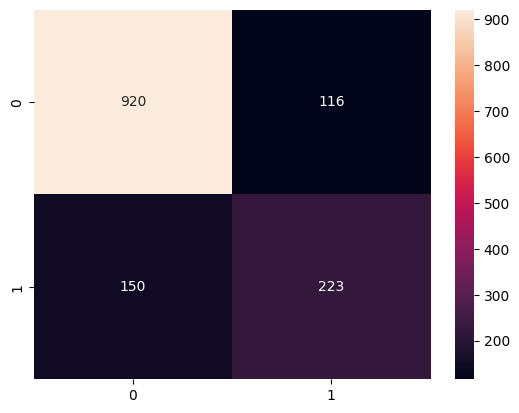

              precision    recall  f1-score   support

           0       0.86      0.89      0.87      1036
           1       0.66      0.60      0.63       373

    accuracy                           0.81      1409
   macro avg       0.76      0.74      0.75      1409
weighted avg       0.81      0.81      0.81      1409



In [ ]:

pred = (model.predict(X_test) > 0.5).astype(int)

cm = confusion_matrix(y_test, pred)
sns.heatmap(cm, annot=True, fmt="d")
plt.show()

print(classification_report(y_test, pred))


## Task 6 - Save & Predict

In [ ]:

model.save("Best_Churn_Model.keras")

loaded = load_model("Best_Churn_Model.keras")

sample = np.array([X_test[0]])
prediction = loaded.predict(sample)

print("Prediction:", "Churn" if prediction > 0.5 else "No Churn")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 492ms/step
Prediction: Churn


## Task 7 - CNN vs RNN

CNNs are used for spatial data such as images. They automatically learn visual features and are commonly used for image classification and object detection.

RNNs are designed for sequential data such as text, speech, and time-series. They retain information from previous inputs, making them suitable for language modeling and sequence prediction.
